In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
crash_df = sns.load_dataset('car_crashes')
crash_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


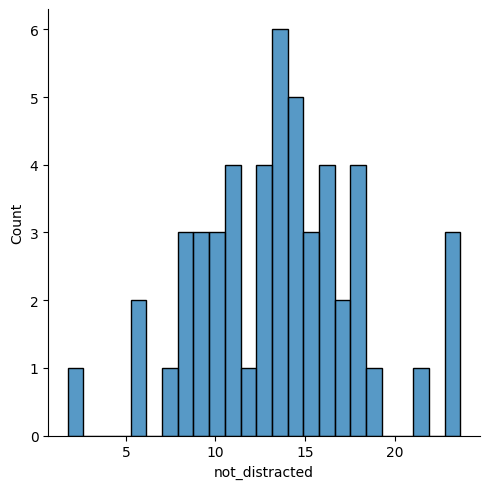

In [10]:
sns.displot(crash_df['not_distracted'],bins = 25)

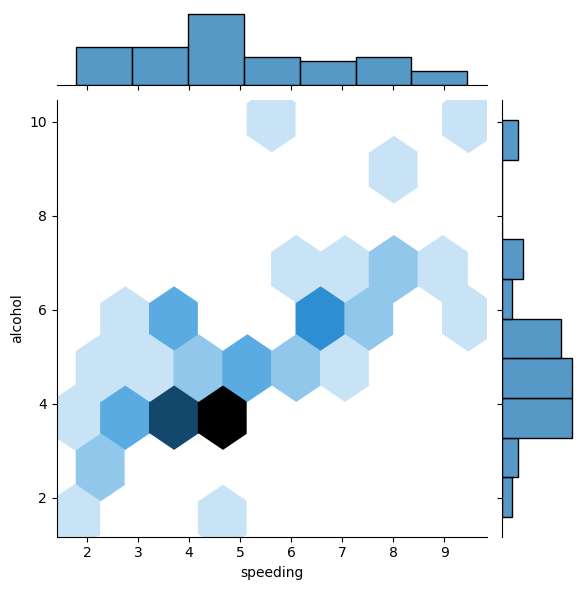

In [15]:
#Joint Plot
sns.jointplot(x = 'speeding',y = 'alcohol', data = crash_df, kind = 'hex')

<Axes: xlabel='alcohol', ylabel='Density'>

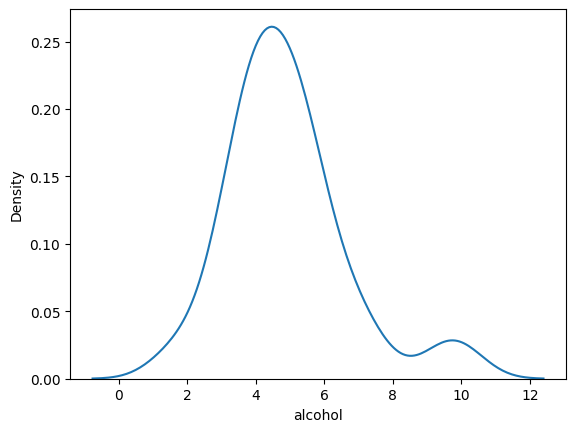

In [17]:
# KDE Plot
sns.kdeplot(crash_df['alcohol'])

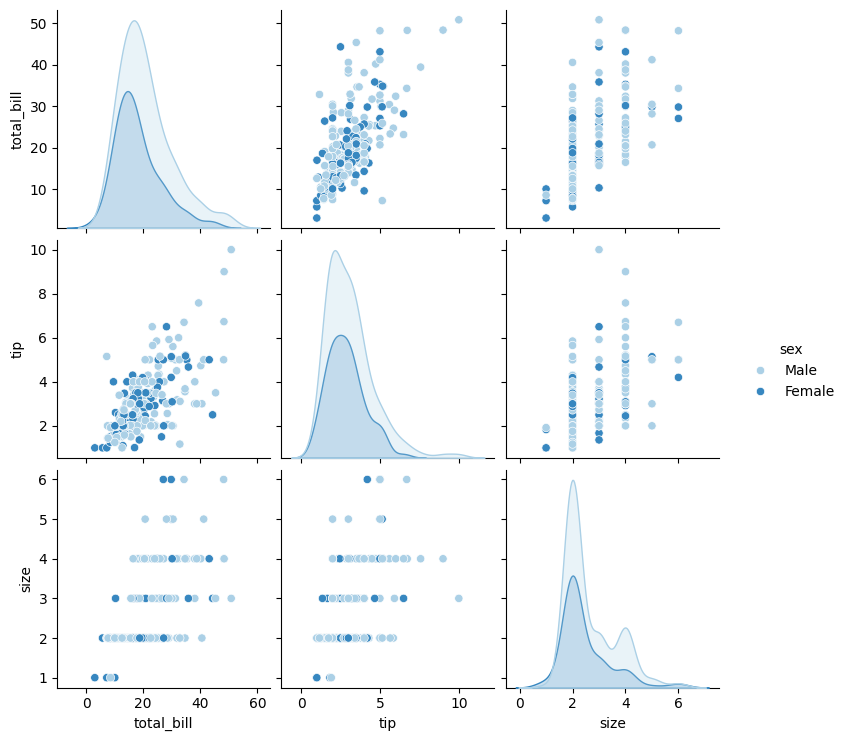

In [22]:
# Pair Plots
# sns.pairplot(crash_df)

tips_df = sns.load_dataset("tips")
sns.pairplot(tips_df, hue='sex', palette='Blues')

<Axes: xlabel='tip'>

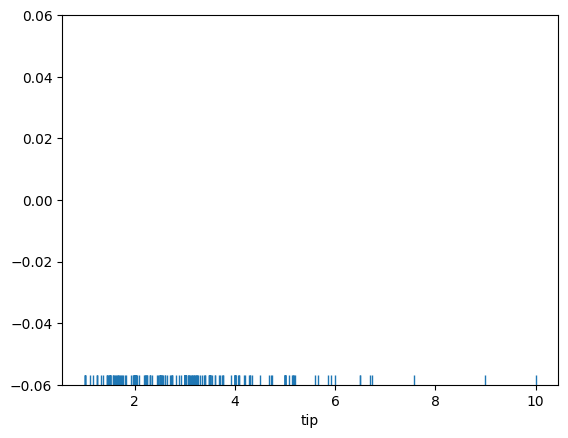

In [23]:
# Rug Plot
sns.rugplot(tips_df['tip'])

<Figure size 800x400 with 0 Axes>

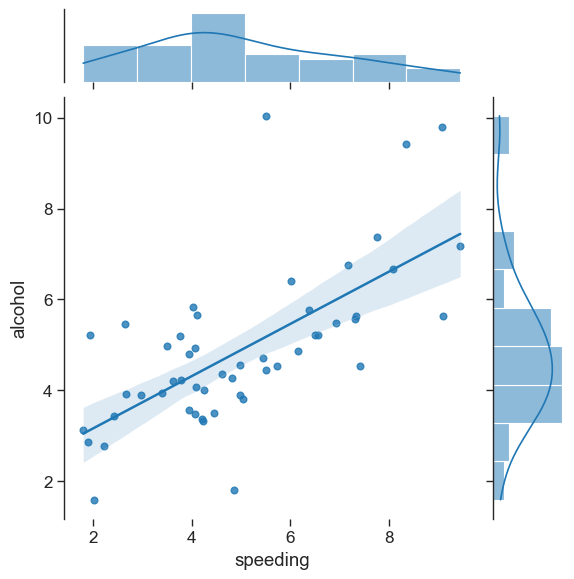

In [41]:
# Styling
sns.set_style('ticks')#darkgrid, whitegrid, dark, white, ticks
plt.figure(figsize=(8,4))
sns.set_context('paper', font_scale=1.4)#paper, talk, poster

sns.jointplot(x = 'speeding',y = 'alcohol', data=crash_df, kind = 'reg')

sns.despine(right = True, bottom=True)


In [42]:
# Categorical Plots

<Axes: xlabel='sex', ylabel='total_bill'>

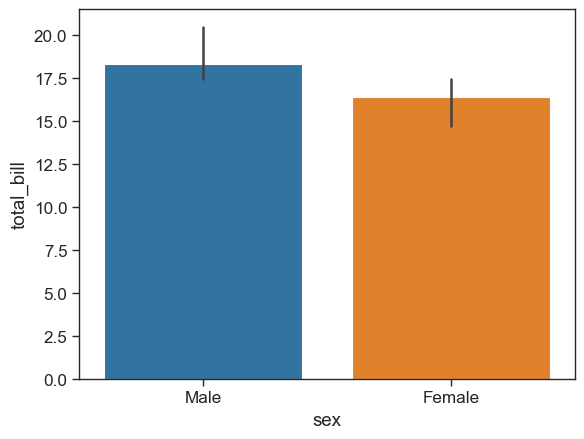

In [48]:
# Bar Plots
sns.barplot(x = 'sex', y = 'total_bill', data=tips_df, estimator=np.median, hue ='sex')# mean, median, var, cov

<Axes: xlabel='sex', ylabel='count'>

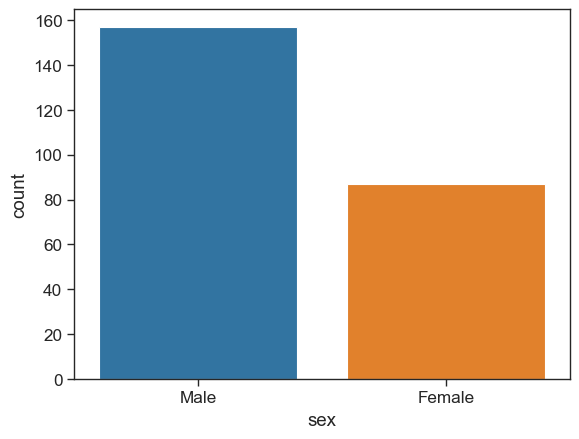

In [47]:
# Count Plot
sns.countplot(x = 'sex', data= (tips_df), hue = 'sex')

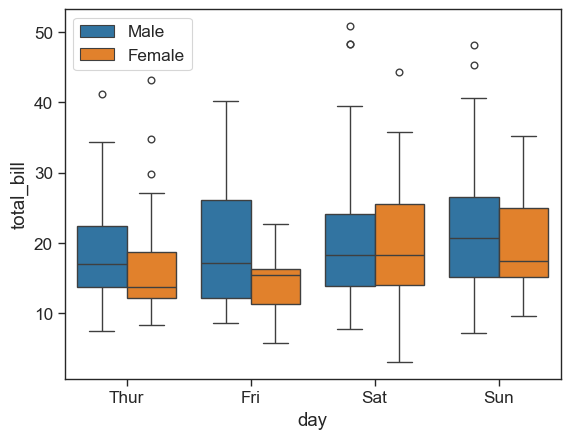

In [49]:
# Box Plot
sns.boxplot(x = 'day', y = 'total_bill', data=tips_df, hue='sex')
plt.legend(loc = 0)

<Axes: xlabel='day', ylabel='total_bill'>

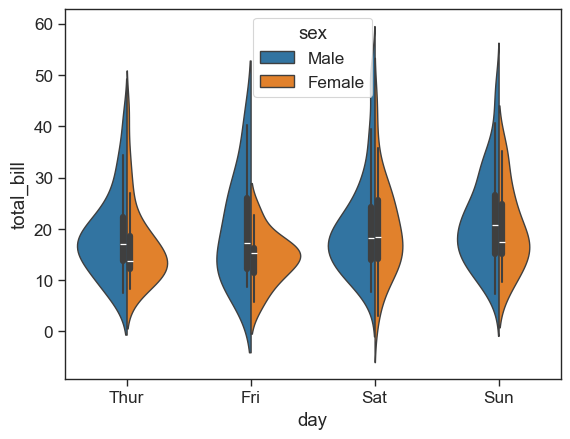

In [51]:
# Violin Plot
sns.violinplot(x = 'day', y = 'total_bill', data= tips_df, hue = 'sex', split = True)

<Axes: xlabel='day', ylabel='total_bill'>

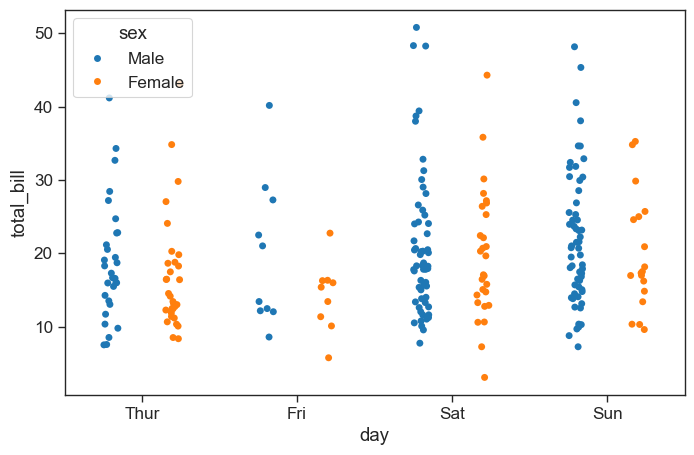

In [58]:
# Strip Plot
plt.figure(figsize=(8,5))

sns.stripplot(x = 'day', y = 'total_bill', data = tips_df, jitter=True, hue = 'sex',dodge = True)

<Axes: xlabel='day', ylabel='total_bill'>

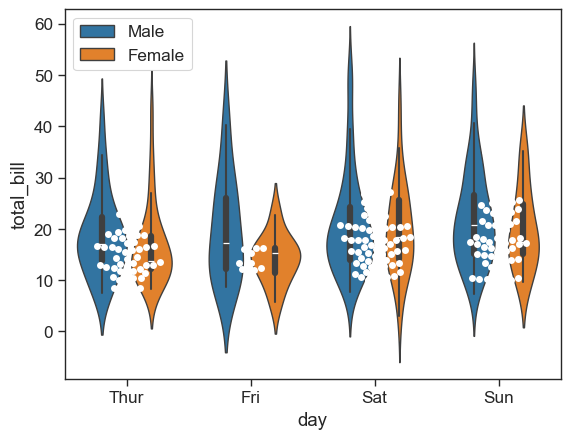

In [61]:
# Swarm Plot
sns.violinplot(x = 'day', y ='total_bill', data = tips_df,hue='sex')
sns.swarmplot(x = 'day', y ='total_bill', data=tips_df, color='white')

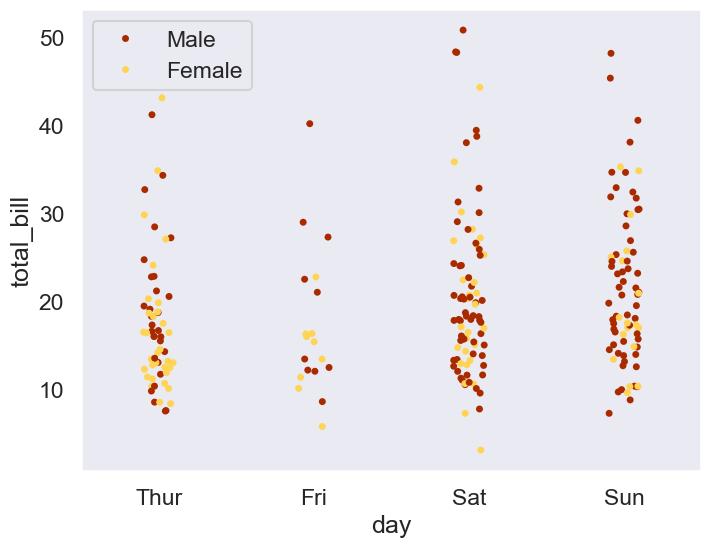

In [74]:
#Palettes

plt.figure(figsize=(8,6))
sns.set_style('dark')
sns.set_context('talk')
sns.stripplot(x = 'day', y = 'total_bill', data = tips_df, hue='sex',palette='afmhot')

# upper right: 1, upper left: 2, lower left: 3, lower right: 4,
# https://matplotlib.org/3.3.1/api/_as_gen/matplotlib.pyplot.legend.html
plt.legend(loc = 2)

In [75]:
# Matrix Plots


<Axes: >

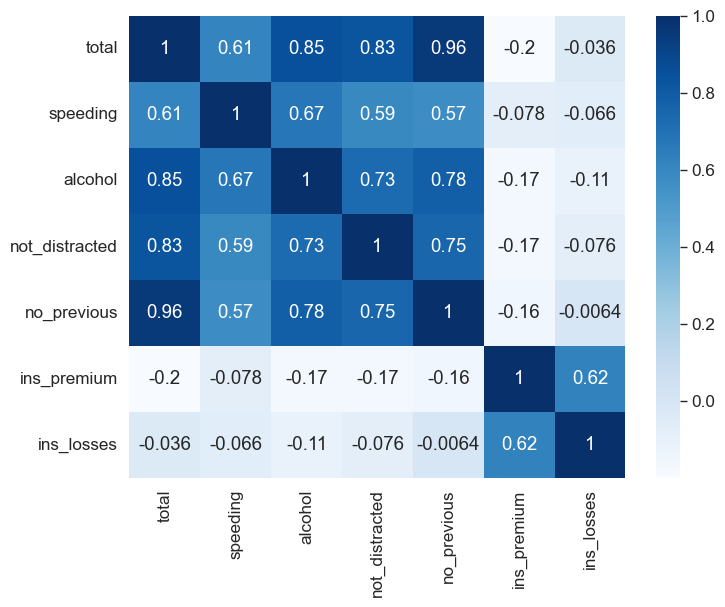

In [81]:
# Heatmaps

plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)

numeric_df = crash_df.select_dtypes(include=['number'])
crash_mx = numeric_df.corr()
crash_mx

sns.heatmap(crash_mx, annot = True, cmap="Blues")

/var/folders/b5/lsr7f0hj6s53h_5brm9m7cbm0000gn/T/ipykernel_3382/652405555.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights = flights.pivot_table(index = 'month', columns='year', values='passengers')


<Axes: xlabel='year', ylabel='month'>

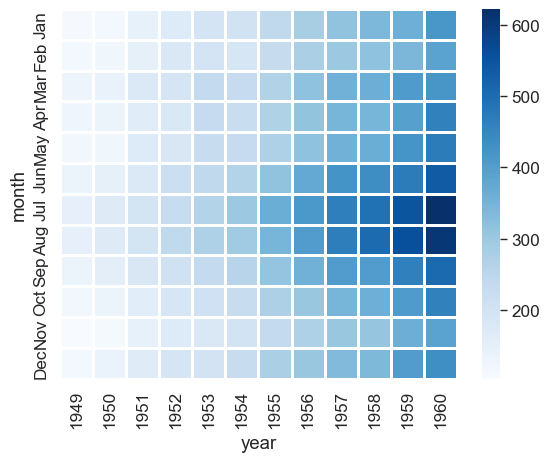

In [89]:
flights = sns.load_dataset('flights')
flights = flights.pivot_table(index = 'month', columns='year', values='passengers')
sns.heatmap(flights, cmap = 'Blues', linecolor='white', linewidth=1)

<Axes: >

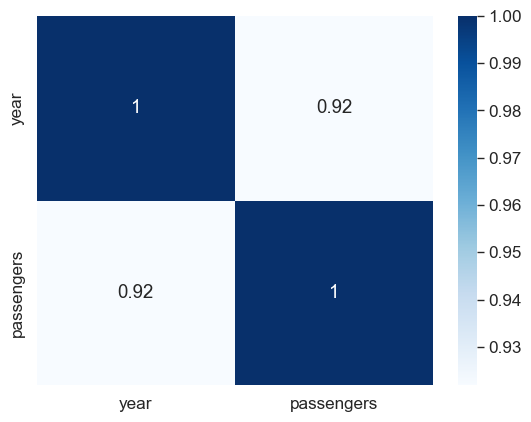

In [86]:
flights_numeric = flights.select_dtypes(include = ['number'])


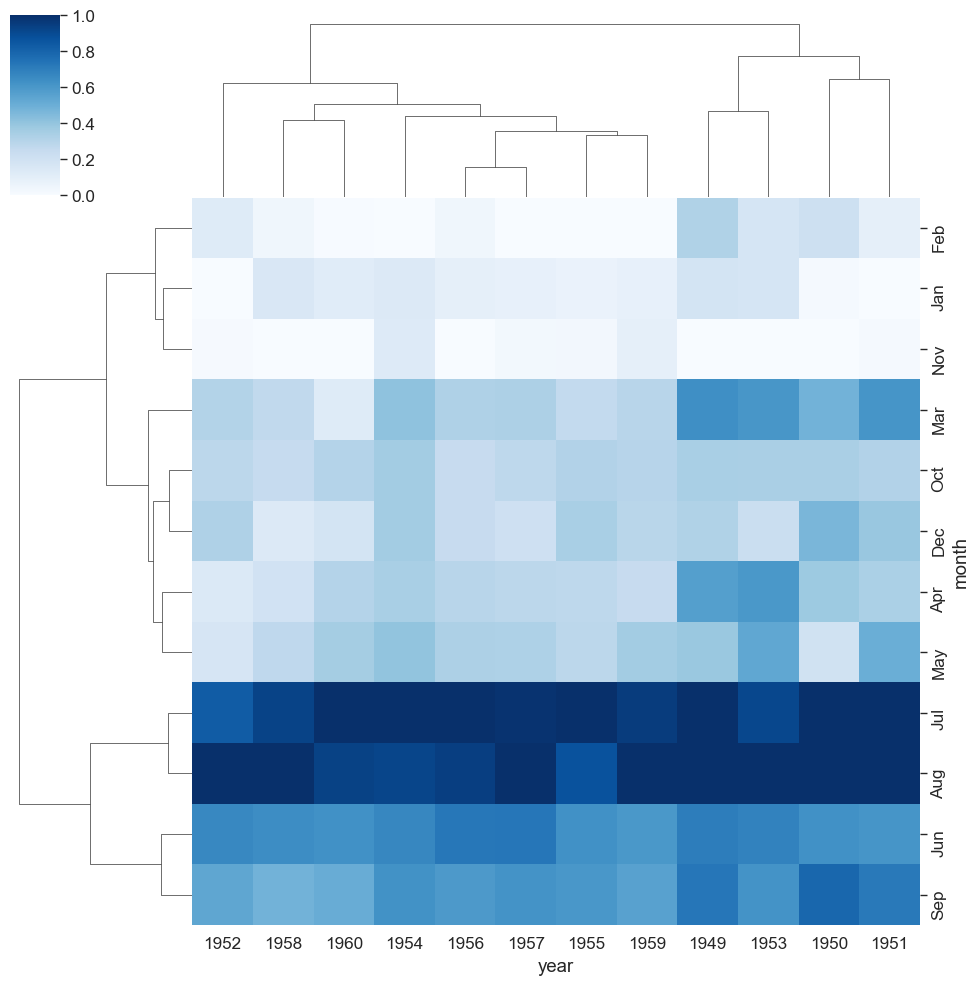

In [93]:
# # Cluster Map
# iris = sns.load_dataset('iris')
# species = iris.pop('species')
# sns.clustermap(iris)

sns.clustermap(flights, cmap = 'Blues', standard_scale = 1)

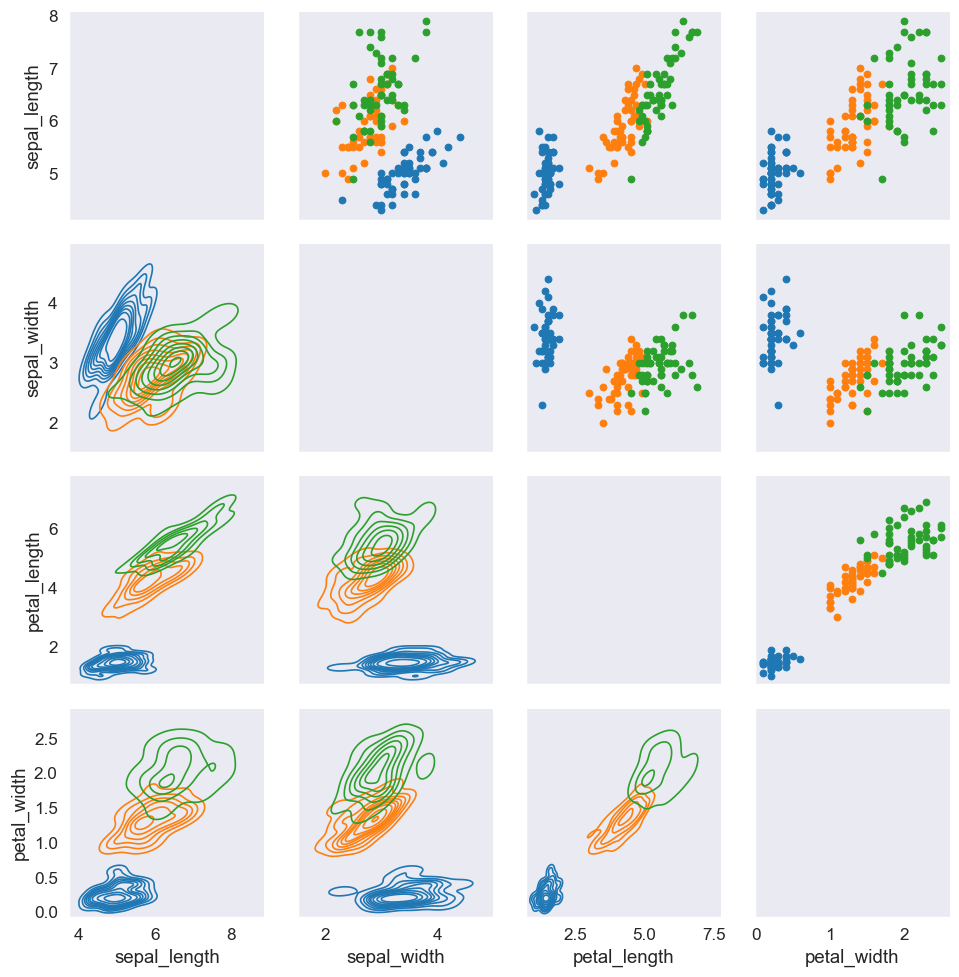

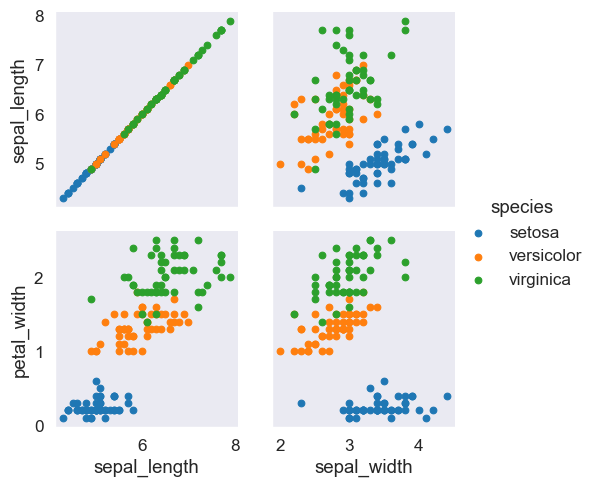

In [103]:
# Pair Grid
iris = sns.load_dataset('iris')
iris_g = sns.PairGrid(iris, hue='species')
# iris_g.map(plt.scatter)
# iris_g.map_diag(plt.hist)
#iris_g.map_offdiag(plt.scatter)
iris_g.map_upper(plt.scatter)
iris_g.map_lower(sns.kdeplot)
iris_g = sns.PairGrid(iris, hue = 'species', x_vars=["sepal_length", "sepal_width"],
                      y_vars=["sepal_length", "petal_width"])
iris_g.map(plt.scatter)
iris_g.add_legend()

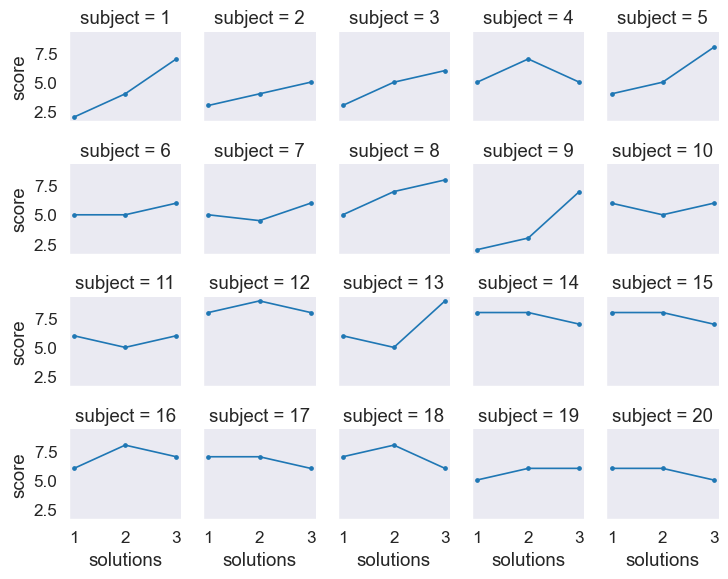

In [115]:
# Facet Grid
# tips_fg = sns.FacetGrid(tips_df, col = 'time', row = 'smoker', height=4, aspect=1.3, col_order=['Dinner','Lunch'], palette = 'Set1', hue = 'sex')
# tips_fg.map(plt.scatter, 'total_bill', 'tip', edgecolor = 'w')
# tips_fg.map(plt.scatter, 'total_bill', 'tip')

# kws = dict(s = 50, linewidth = .5, edgecolor = 'w')
# tips_fg = sns.FacetGrid(tips_df, col = 'sex', hue = 'smoker', height= 4, aspect=1.3,hue_order=['Yes', 'No'], hue_kws=dict(marker = ['^','v']))
# tips_fg.map(plt.scatter, 'total_bill', 'tip', **kws)

att_df = sns.load_dataset('attention')
att_fg = sns.FacetGrid(att_df, col = 'subject', col_wrap=5, height=1.5)
att_fg.map(plt.plot, 'solutions', 'score', marker = '.')

In [116]:
# Regression Plots

tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Figure size 800x600 with 0 Axes>

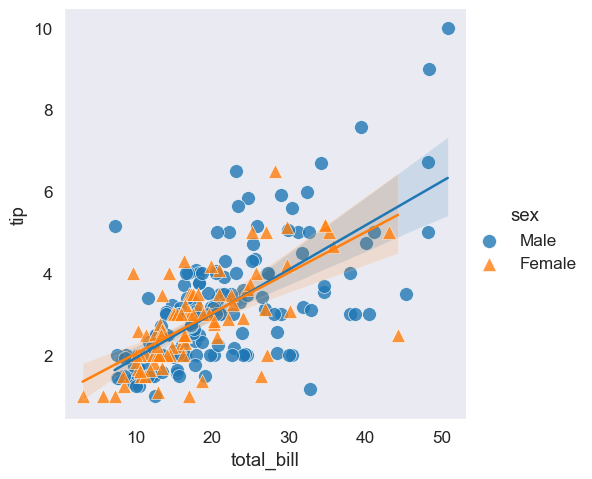

In [119]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
sns.lmplot(x = 'total_bill', y = 'tip', hue = 'sex', data = tips_df, markers=['o','^'], scatter_kws={'s':100, 'linewidths':0.5,'edgecolor':'w'})

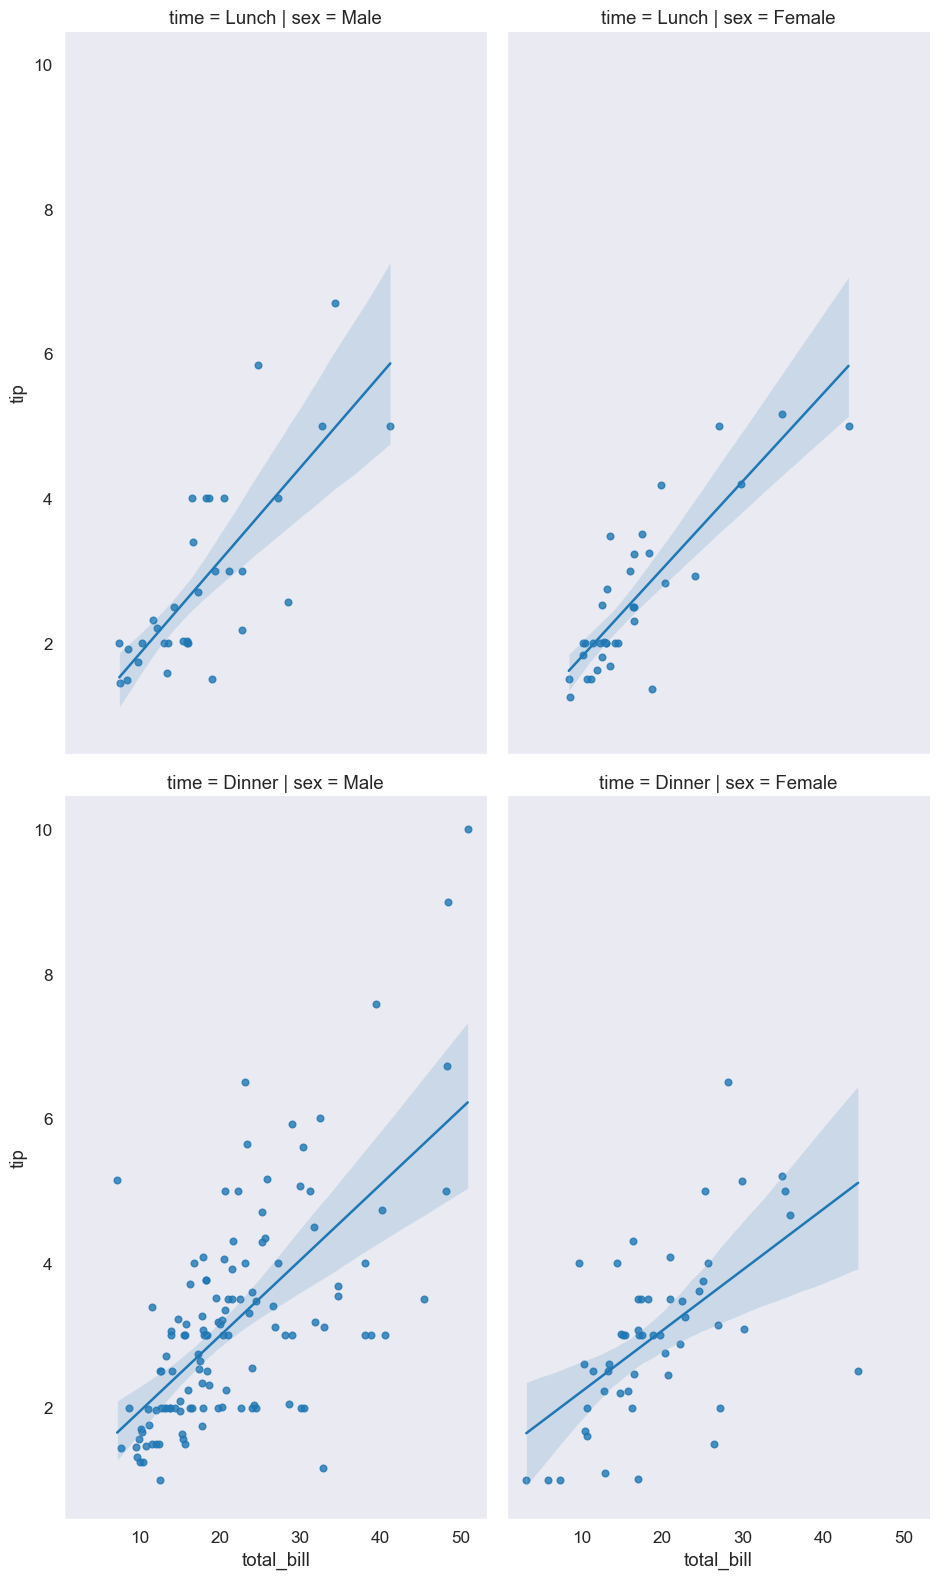

In [122]:
sns.set_context('paper', font_scale=1.4)
sns.lmplot(x = 'total_bill', y = 'tip', col='sex', row='time', data=tips_df, height = 8,aspect=0.6)